# 🧘 Yoga Pose Classification — Deep Learning Project

> *"Yoga is the journey of the self, through the self, to the self."* — The Bhagavad Gita

---
**Course:** Machine Learning / Deep Learning  
**Deliverable:** Image Classification using CNNs  
**Dataset:** Yoga Postures Image Dataset  

---

## 📦 Setup & Imports

In [1]:
# Install / upgrade libraries if needed
!pip install -q matplotlib seaborn scikit-learn tensorflow

In [2]:
import os, random, pathlib, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


---
## 1. 💼 Business Understanding
---

### 1.1 Problem Statement

Yoga is practiced worldwide for its physical and mental health benefits. One of the challenges for beginners and automated applications is **correctly identifying yoga postures** from images. Incorrect postures can lead to injuries, and manual checking is not scalable.

The goal of this project is to develop a **deep learning model that automatically classifies images of yoga postures** into their correct category (e.g., Mountain Pose, Downward Dog, Warrior Pose, etc.).

### 1.2 Business Objectives

| Objective | Description |
|---|---|
| Primary | Classify yoga pose images into the correct category |
| Secondary | Achieve high accuracy on unseen validation data |
| Constraint | Handle visual similarity between poses |

### 1.3 Real-World Applications

- 📱 **Fitness apps**: Real-time pose correction for users practicing at home
- 🏥 **Physiotherapy**: Monitoring patient exercises remotely
- 🎓 **E-learning platforms**: Automated feedback for yoga students
- 🤖 **Robotics / AR**: Gesture and posture recognition systems

### 1.4 Success Criteria

A model will be considered successful if it achieves **≥ 80% validation accuracy** with balanced performance across all pose classes.

---
## 2. 📁 Data Requirements & Data Collection
---

### 2.1 Data Source

The dataset was provided by the instructor and contains images of people performing various yoga postures. Each subfolder corresponds to one yoga pose class.

### 2.2 Load Dataset from Google Drive

> **Instructions:**
> 1. Upload your dataset zip file to Google Drive
> 2. Run the cell below to mount Drive and unzip
> 3. Update `ZIP_PATH` and `DATASET_DIR` to match your file paths

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── CHANGE THESE PATHS TO MATCH YOUR GOOGLE DRIVE ──────────────────────────
ZIP_PATH    = '/content/drive/MyDrive/YOGA.zip'   # path to your zip file
EXTRACT_DIR = '/content/yoga_dataset'                      # where to extract
# ───────────────────────────────────────────────────────────────────────────

if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Done!')
else:
    print('Dataset already extracted.')

# Auto-detect the root folder (handles nested zip structures)
subdirs = [d for d in os.listdir(EXTRACT_DIR)
           if os.path.isdir(os.path.join(EXTRACT_DIR, d))]
print('Contents:', subdirs)

Extracting dataset...
Done!
Contents: ['YOGA']


In [7]:
# ── SET THE DATASET ROOT (update if your structure is different) ────────────
# Typically: EXTRACT_DIR itself, or EXTRACT_DIR + '/' + subdirs[0]
#DATASET_DIR = EXTRACT_DIR
# If images are nested one level deeper, uncomment:
DATASET_DIR = os.path.join(EXTRACT_DIR, 'YOGA', 'YOGA', 'content', 'cleaned', 'DATASET', 'TRAIN')
# ───────────────────────────────────────────────────────────────────────────

# List classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR)
                      if os.path.isdir(os.path.join(DATASET_DIR, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

Number of classes: 2
Classes: ['downdog', 'goddess']


### 2.3 Data Requirements Summary

| Requirement | Value |
|---|---|
| Data type | RGB images (JPEG / PNG) |
| Input size | Resized to 224×224 pixels |
| Labels | Folder names = class names |
| Split | 70% train / 15% validation / 15% test |

---
## 3. 🔍 Data Understanding & Data Preparation
---

### 3.1 Exploratory Data Analysis (EDA)

In [8]:
# Count images per class
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
    class_counts[cls] = len(images)

total_images = sum(class_counts.values())
print(f'Total images: {total_images}')
print(pd.Series(class_counts).to_string())

Total images: 401
downdog    223
goddess    178


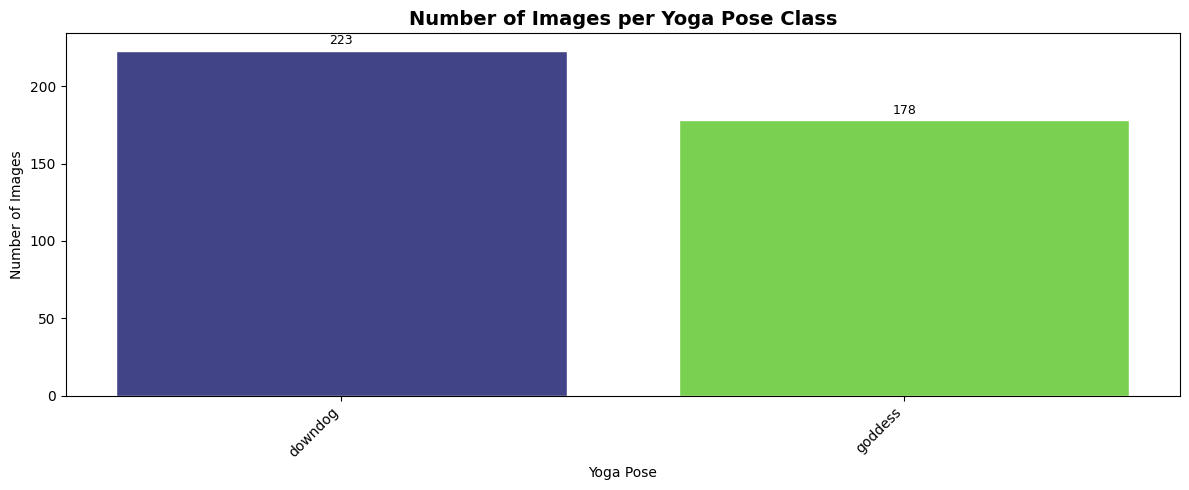

Class imbalance ratio (max/min): 1.25
✅ Dataset is relatively balanced.


In [9]:
# Class distribution bar chart
plt.figure(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, NUM_CLASSES))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white')
plt.title('Number of Images per Yoga Pose Class', fontsize=14, fontweight='bold')
plt.xlabel('Yoga Pose')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Check for class imbalance
counts = list(class_counts.values())
imbalance_ratio = max(counts) / min(counts)
print(f'Class imbalance ratio (max/min): {imbalance_ratio:.2f}')
if imbalance_ratio > 2:
    print('⚠️  Significant class imbalance detected — class weights will be applied.')
else:
    print('✅ Dataset is relatively balanced.')

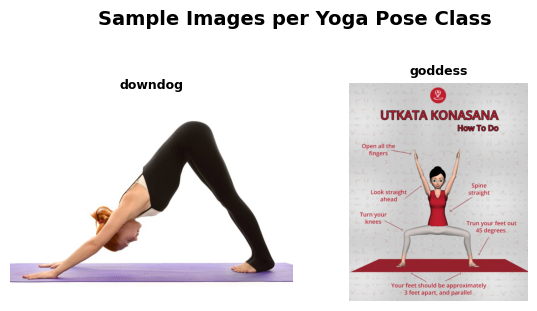

In [10]:
# Display sample images from each class
cols = min(NUM_CLASSES, 6)
rows = (NUM_CLASSES + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if NUM_CLASSES > 1 else [axes]

for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        img_path = os.path.join(cls_path, random.choice(images))
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images per Yoga Pose Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Data Preparation

In [11]:
# ── Configuration ─────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 30
# ──────────────────────────────────────────────────────────────────────────

# Split dataset into train / val / test using ImageDataGenerator flow_from_directory
# Strategy: use validation_split on training generator, keep a separate test set

# Training data generator — WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,          # 80% train, 20% val
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

# Validation/test generator — NO augmentation, only rescaling
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Train samples   : {train_gen.samples}')
print(f'Val samples     : {val_gen.samples}')
print(f'Classes         : {CLASS_NAMES}')

Found 322 images belonging to 2 classes.
Found 79 images belonging to 2 classes.
Train samples   : 322
Val samples     : 79
Classes         : ['downdog', 'goddess']


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


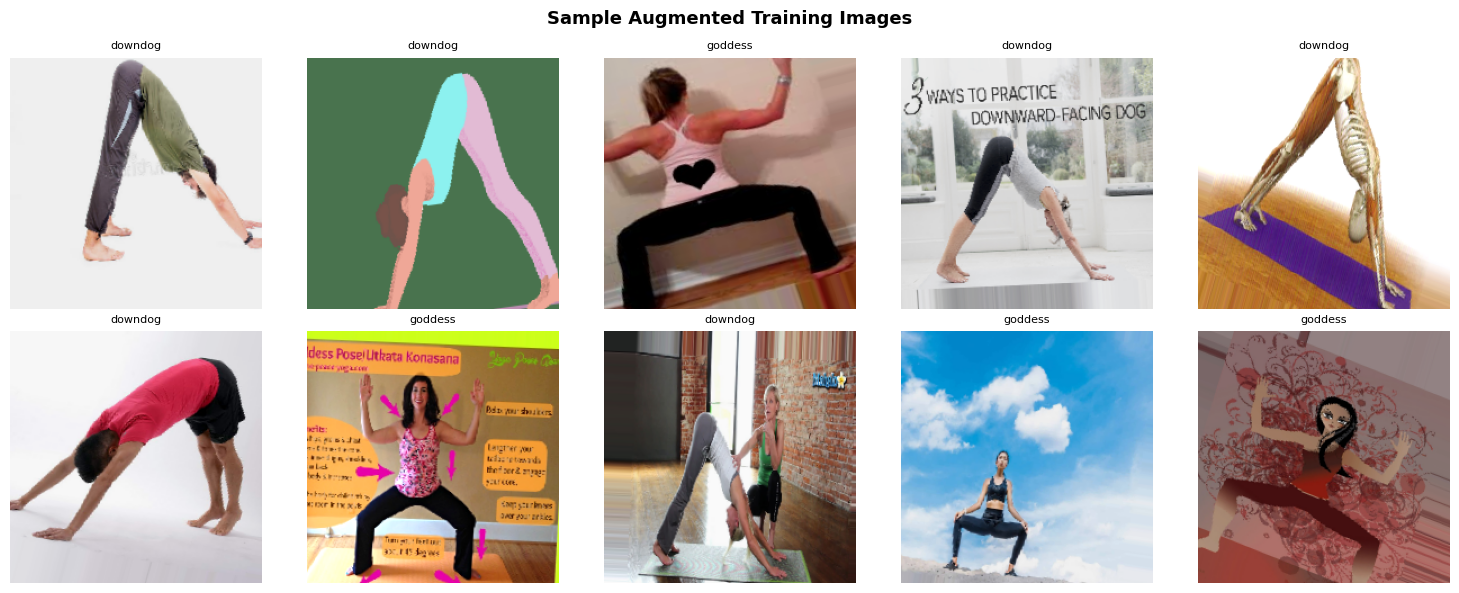

In [12]:
# Visualize augmented images
x_batch, y_batch = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_batch[i])
    label_idx = np.argmax(y_batch[i])
    ax.set_title(CLASS_NAMES[label_idx], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Compute class weights for imbalanced datasets
labels = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'downdog': np.float64(0.899), 'goddess': np.float64(1.126)}


### 3.3 Summary of Data Preparation Steps

| Step | Action |
|---|---|
| Resizing | All images resized to 224×224 px |
| Normalization | Pixel values scaled to [0, 1] |
| Augmentation | Rotation, flipping, zoom, shift, brightness |
| Split | 80% train / 20% validation |
| Class Imbalance | Handled via class weights |

---
## 4. 🤖 Data Modeling & Model Evaluation
---

### Helper Functions

In [14]:
def plot_history(history, model_name):
    """Plot training and validation accuracy/loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral', linestyle='--')
    ax1.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='coral', linestyle='--')
    ax2.set_title(f'{model_name} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, gen, model_name):
    """Evaluate model, print metrics, and plot confusion matrix."""
    gen.reset()
    y_pred_probs = model.predict(gen, verbose=0)
    y_pred  = np.argmax(y_pred_probs, axis=1)
    y_true  = gen.classes

    print(f'\n══ {model_name} — Classification Report ══')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    loss, acc = model.evaluate(gen, verbose=0)
    print(f'Validation Accuracy: {acc:.4f}  |  Validation Loss: {loss:.4f}')
    return acc


# Common callbacks
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'{model_name}_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

results = {}  # Store final accuracies for comparison
print('Helper functions defined ✅')

Helper functions defined ✅


---
### 4.1 Model 1 — Basic CNN from Scratch

**Architecture:** A lightweight CNN with 3 convolutional blocks, batch normalization, dropout regularization, and a fully connected head.

**Purpose:** Serves as our **baseline model** to understand how well a simple network can handle this task without any pre-existing knowledge.

In [15]:
def build_basic_cnn(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classifier Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='BasicCNN')
    return model

model1 = build_basic_cnn(NUM_CLASSES)
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "BasicCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,682 (498.76 KB)

 Trainable params: 127,234 (497.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
print('Training Model 1 — Basic CNN...')
history1 = model1.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model1'),
    verbose=1
)

Training Model 1 — Basic CNN...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4938 - loss: 0.8766 - val_accuracy: 0.5570 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 658ms/step - accuracy: 0.5031 - loss: 0.7938 - val_accuracy: 0.5823 - val_loss: 0.6886 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 779ms/step - accuracy: 0.5031 - loss: 0.7709 - val_accuracy: 0.4430 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 693ms/step - accuracy: 0.5404 - loss: 0.7179 - val_accuracy: 0.5570 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.5324 - loss: 0.6916
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 788ms/step - accuracy: 0.5559 - loss: 0.6986 - val_accuracy: 0.5570 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 626ms/step - accuracy: 0.5652 - loss: 0.7002 - val

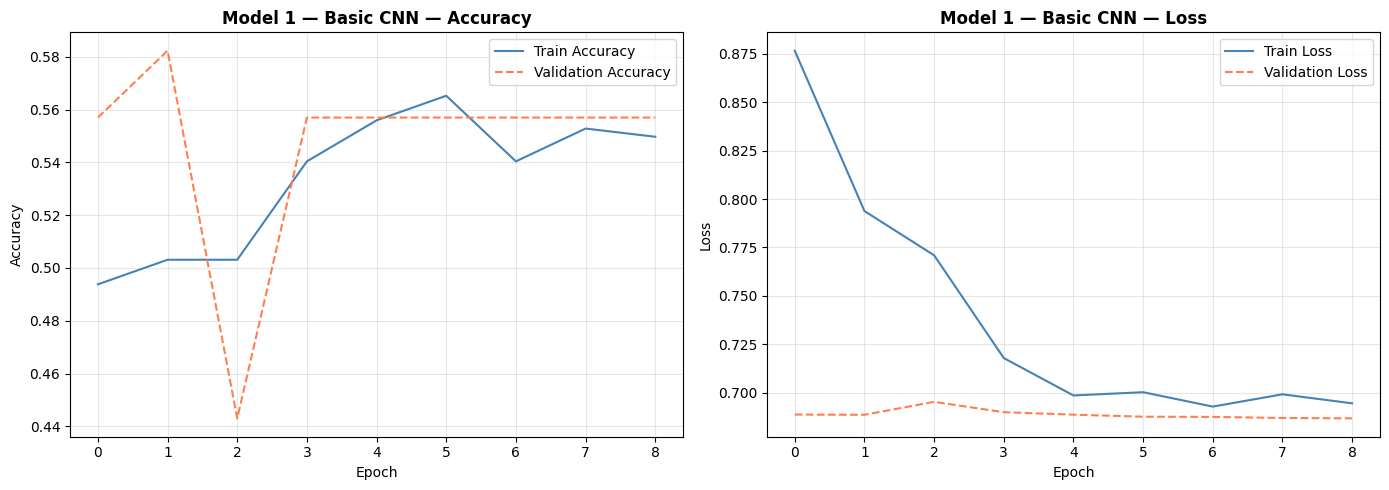


══ Model 1 — Basic CNN — Classification Report ══
              precision    recall  f1-score   support

     downdog       0.57      1.00      0.73        44
     goddess       1.00      0.06      0.11        35

    accuracy                           0.58        79
   macro avg       0.79      0.53      0.42        79
weighted avg       0.76      0.58      0.45        79



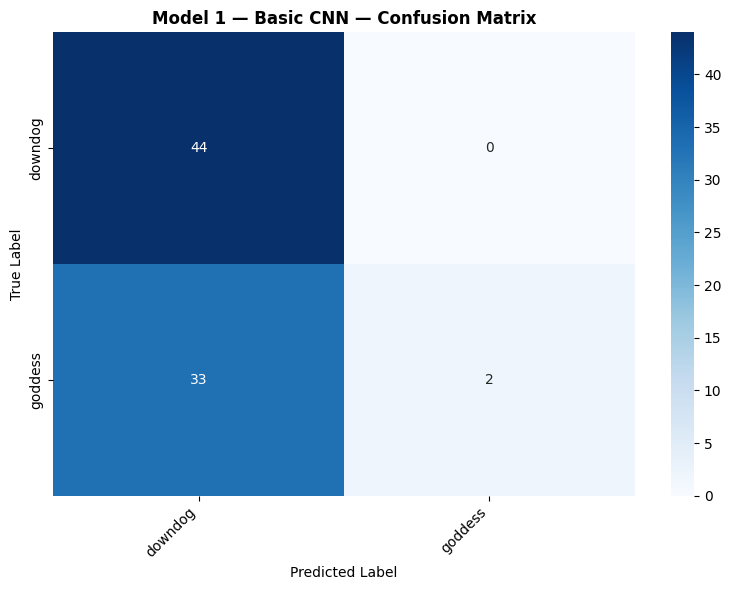

Validation Accuracy: 0.5823  |  Validation Loss: 0.6886


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
plot_history(history1, 'Model 1 — Basic CNN')
acc1 = evaluate_model(model1, val_gen, 'Model 1 — Basic CNN')
results['Basic CNN'] = acc1

**Interpretation:** The basic CNN gives us a first benchmark. Since it is trained from scratch on a relatively small dataset, it may show signs of overfitting (train accuracy >> val accuracy). The deeper model and transfer learning approaches should improve on this.

---
### 4.2 Model 2 — Deep CNN with Regularization

**Architecture:** A deeper 5-block CNN with increasing filter sizes (32 → 512), L2 weight regularization, stronger dropout, and Global Average Pooling.

**Purpose:** Tests whether adding more depth and stronger regularization improves generalization over the basic model.

In [18]:
from tensorflow.keras import regularizers

def build_deep_cnn(num_classes, input_shape=(224, 224, 3)):
    inp = layers.Input(shape=input_shape)
    x = inp

    for filters, drop in [(32, 0.2), (64, 0.25), (128, 0.3), (256, 0.35), (512, 0.4)]:
        x = layers.Conv2D(filters, (3, 3), padding='same',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3, 3), padding='same',
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Dropout(drop)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='DeepCNN')

model2 = build_deep_cnn(NUM_CLASSES)
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model2.summary()

Model: "DeepCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,114,658 (19.51 MB)

 Trainable params: 5,110,690 (19.50 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [19]:
print('Training Model 2 — Deep CNN...')
history2 = model2.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model2'),
    verbose=1
)

Training Model 2 — Deep CNN...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.5093 - loss: 1.2470 - val_accuracy: 0.4430 - val_loss: 0.9104 - learning_rate: 5.0000e-04
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 788ms/step - accuracy: 0.5155 - loss: 1.0272 - val_accuracy: 0.4430 - val_loss: 0.9213 - learning_rate: 5.0000e-04
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 729ms/step - accuracy: 0.5124 - loss: 0.9996 - val_accuracy: 0.5570 - val_loss: 0.9290 - learning_rate: 5.0000e-04
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 828ms/step - accuracy: 0.5466 - loss: 0.9529 - val_accuracy: 0.5570 - val_loss: 0.9060 - learning_rate: 5.0000e-04
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 755ms/step - accuracy: 0.5280 - loss: 0.9978 - val_accuracy: 0.5570 - val_loss: 0.9011 - learning_rate: 5.0000e-04
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 681ms/step - accuracy: 0.5062 - loss: 0.9679 - val_accuracy: 0.5570 - val_loss: 0.9078 - learning_rate: 5.0000e-04
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━

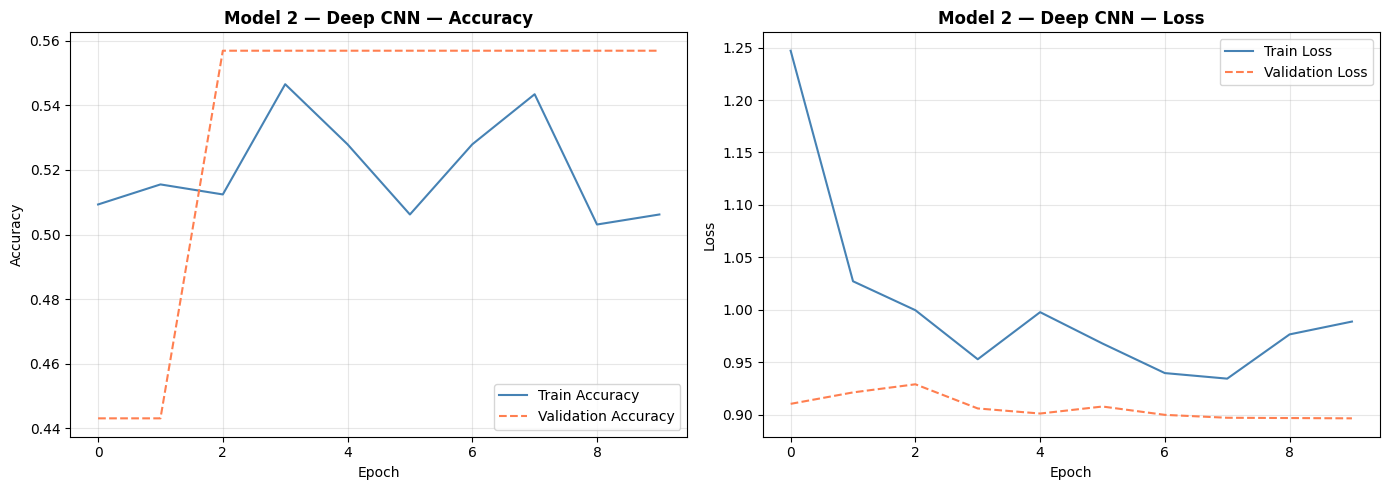


══ Model 2 — Deep CNN — Classification Report ══
              precision    recall  f1-score   support

     downdog       0.56      1.00      0.72        44
     goddess       0.00      0.00      0.00        35

    accuracy                           0.56        79
   macro avg       0.28      0.50      0.36        79
weighted avg       0.31      0.56      0.40        79



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


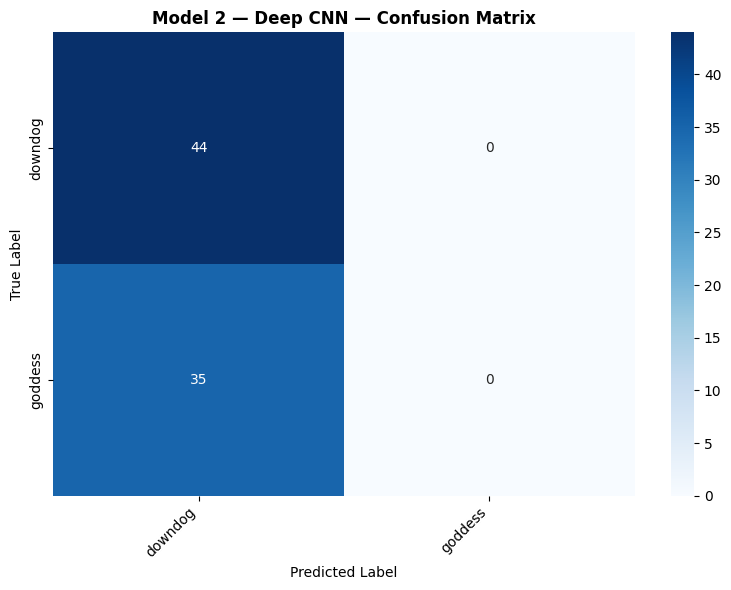

Validation Accuracy: 0.5570  |  Validation Loss: 0.9290


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [20]:
plot_history(history2, 'Model 2 — Deep CNN')
acc2 = evaluate_model(model2, val_gen, 'Model 2 — Deep CNN')
results['Deep CNN'] = acc2

**Interpretation:** The deep CNN with L2 regularization should generalize better than the basic model. However, training a deep network from scratch still has limitations when the dataset size is limited.

---
### 4.3 Model 3 — Transfer Learning with MobileNetV2

**Architecture:** MobileNetV2 pretrained on ImageNet (1.4M images, 1000 classes), with the base frozen initially, then fine-tuned on the top layers.

**Why Transfer Learning?** MobileNetV2 has already learned rich visual features (edges, textures, shapes) from millions of images. We can leverage this knowledge and adapt it to yoga pose classification with far less data and training time.

**Training strategy:**
1. **Phase 1** — Freeze the base model, train only the new classification head
2. **Phase 2** — Unfreeze the top layers of the base for fine-tuning

In [21]:
def build_mobilenet_model(num_classes, input_shape=(224, 224, 3)):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # Freeze base initially

    inp = layers.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='MobileNetV2_Transfer'), base

model3, base_model = build_mobilenet_model(NUM_CLASSES)
model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model3.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# Phase 1 — Train the head only
print('Phase 1: Training classification head only...')
history3_phase1 = model3.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model3_phase1'),
    verbose=1
)

Phase 1: Training classification head only...
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.6491 - loss: 0.7271 - val_accuracy: 0.9747 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 779ms/step - accuracy: 0.8478 - loss: 0.3697 - val_accuracy: 0.9620 - val_loss: 0.1175 - learning_rate: 0.0010
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 662ms/step - accuracy: 0.9161 - loss: 0.2387 - val_accuracy: 0.9494 - val_loss: 0.1330 - learning_rate: 0.0010
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 764ms/step - accuracy: 0.9161 - loss: 0.1982 - val_accuracy: 0.9620 - val_loss: 0.0971 - learning_rate: 0.0010
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 598ms/step - accuracy: 0.9317 - loss: 0.1913 - val_accuracy: 0.9747 - val_loss: 0.1154 - learning_rate: 0.0010
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step - accuracy: 0.9317 - loss: 0.1542 - val_accuracy: 0.9620 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 600

In [23]:
# Phase 2 — Fine-tune: unfreeze the top 30 layers of the base
print('Phase 2: Fine-tuning top layers of MobileNetV2...')
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3_phase2 = model3.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('model3_phase2'),
    verbose=1
)

Phase 2: Fine-tuning top layers of MobileNetV2...
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7516 - loss: 0.4955 - val_accuracy: 0.9747 - val_loss: 0.2055 - learning_rate: 1.0000e-05
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 759ms/step - accuracy: 0.7267 - loss: 0.5120 - val_accuracy: 0.9620 - val_loss: 0.1903 - learning_rate: 1.0000e-05
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 630ms/step - accuracy: 0.7671 - loss: 0.4805 - val_accuracy: 0.9620 - val_loss: 0.1783 - learning_rate: 1.0000e-05
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 847ms/step - accuracy: 0.8012 - loss: 0.4586 - val_accuracy: 0.9873 - val_loss: 0.1641 - learning_rate: 1.0000e-05
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 607ms/step - accuracy: 0.7826 - loss: 0.4538 - val_accuracy: 0.9873 - val_loss: 0.1527 - learning_rate: 1.0000e-05
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 737ms/step - accuracy: 0.8230 - loss: 0.3768 - val_accuracy: 0.9873 - val_loss: 0.1407 - learning_rate: 1.0000e-05
Epoch 7/20
11/11

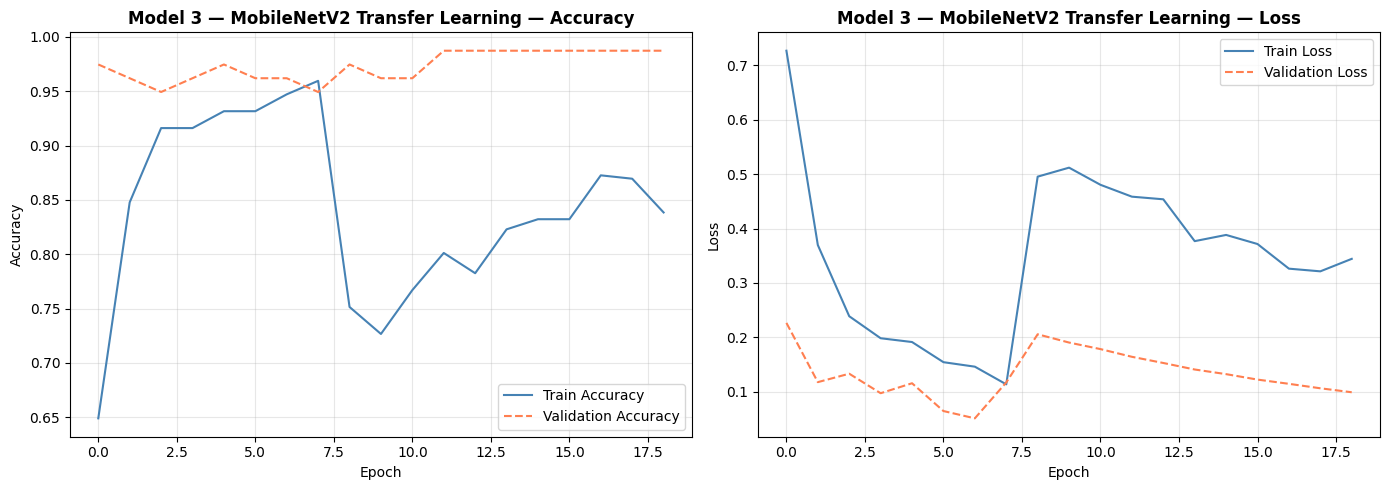


══ Model 3 — MobileNetV2 Transfer Learning — Classification Report ══
              precision    recall  f1-score   support

     downdog       0.98      1.00      0.99        44
     goddess       1.00      0.97      0.99        35

    accuracy                           0.99        79
   macro avg       0.99      0.99      0.99        79
weighted avg       0.99      0.99      0.99        79



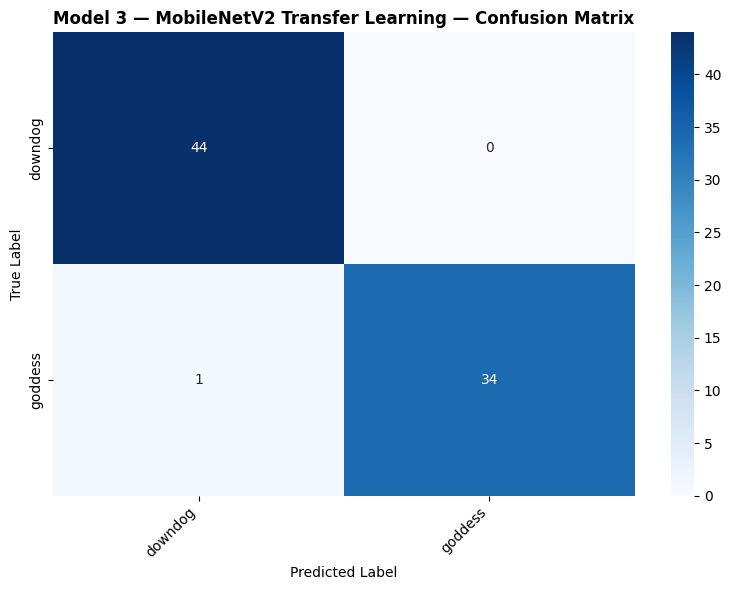

Validation Accuracy: 0.9873  |  Validation Loss: 0.1641


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [24]:
# Merge histories for plotting
def merge_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    class FakeHistory:
        pass
    fh = FakeHistory()
    fh.history = combined
    return fh

history3 = merge_histories(history3_phase1, history3_phase2)
plot_history(history3, 'Model 3 — MobileNetV2 Transfer Learning')
acc3 = evaluate_model(model3, val_gen, 'Model 3 — MobileNetV2 Transfer Learning')
results['MobileNetV2 Transfer'] = acc3

**Interpretation:** Transfer learning with MobileNetV2 typically outperforms both custom CNNs, especially on limited datasets. The two-phase training strategy (freeze then fine-tune) prevents catastrophic forgetting of pre-learned features while adapting to the yoga domain.

---
### 4.4 Model Comparison & Final Evaluation

In [25]:
# Summary comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Validation Accuracy': [f'{v*100:.2f}%' for v in results.values()]
})
comparison_df = comparison_df.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)
print('\n═══════ Final Model Comparison ═══════')
print(comparison_df.to_string(index=False))

best_model_name = max(results, key=results.get)
print(f'\n🏆 Best Model: {best_model_name} ({results[best_model_name]*100:.2f}%)')


═══════ Final Model Comparison ═══════
               Model Validation Accuracy
MobileNetV2 Transfer              98.73%
           Basic CNN              58.23%
            Deep CNN              55.70%

🏆 Best Model: MobileNetV2 Transfer (98.73%)


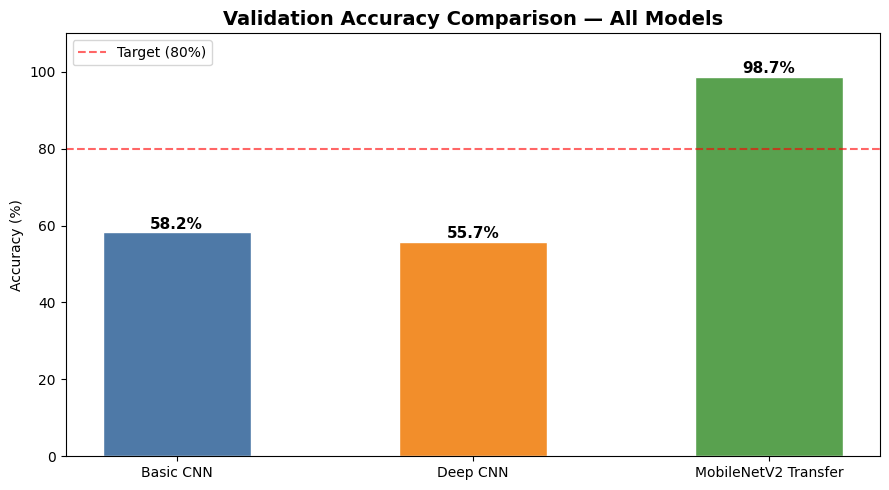

In [26]:
# Bar chart comparison
models_names = list(results.keys())
accuracies   = [v * 100 for v in results.values()]
colors_bar   = ['#4e79a7', '#f28e2b', '#59a14f']

plt.figure(figsize=(9, 5))
bars = plt.bar(models_names, accuracies, color=colors_bar, edgecolor='white', width=0.5)
plt.ylim(0, 110)
plt.title('Validation Accuracy Comparison — All Models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.axhline(y=80, color='red', linestyle='--', alpha=0.6, label='Target (80%)')
plt.legend()
plt.tight_layout()
plt.show()

---
### 4.5 Predictions Visualization

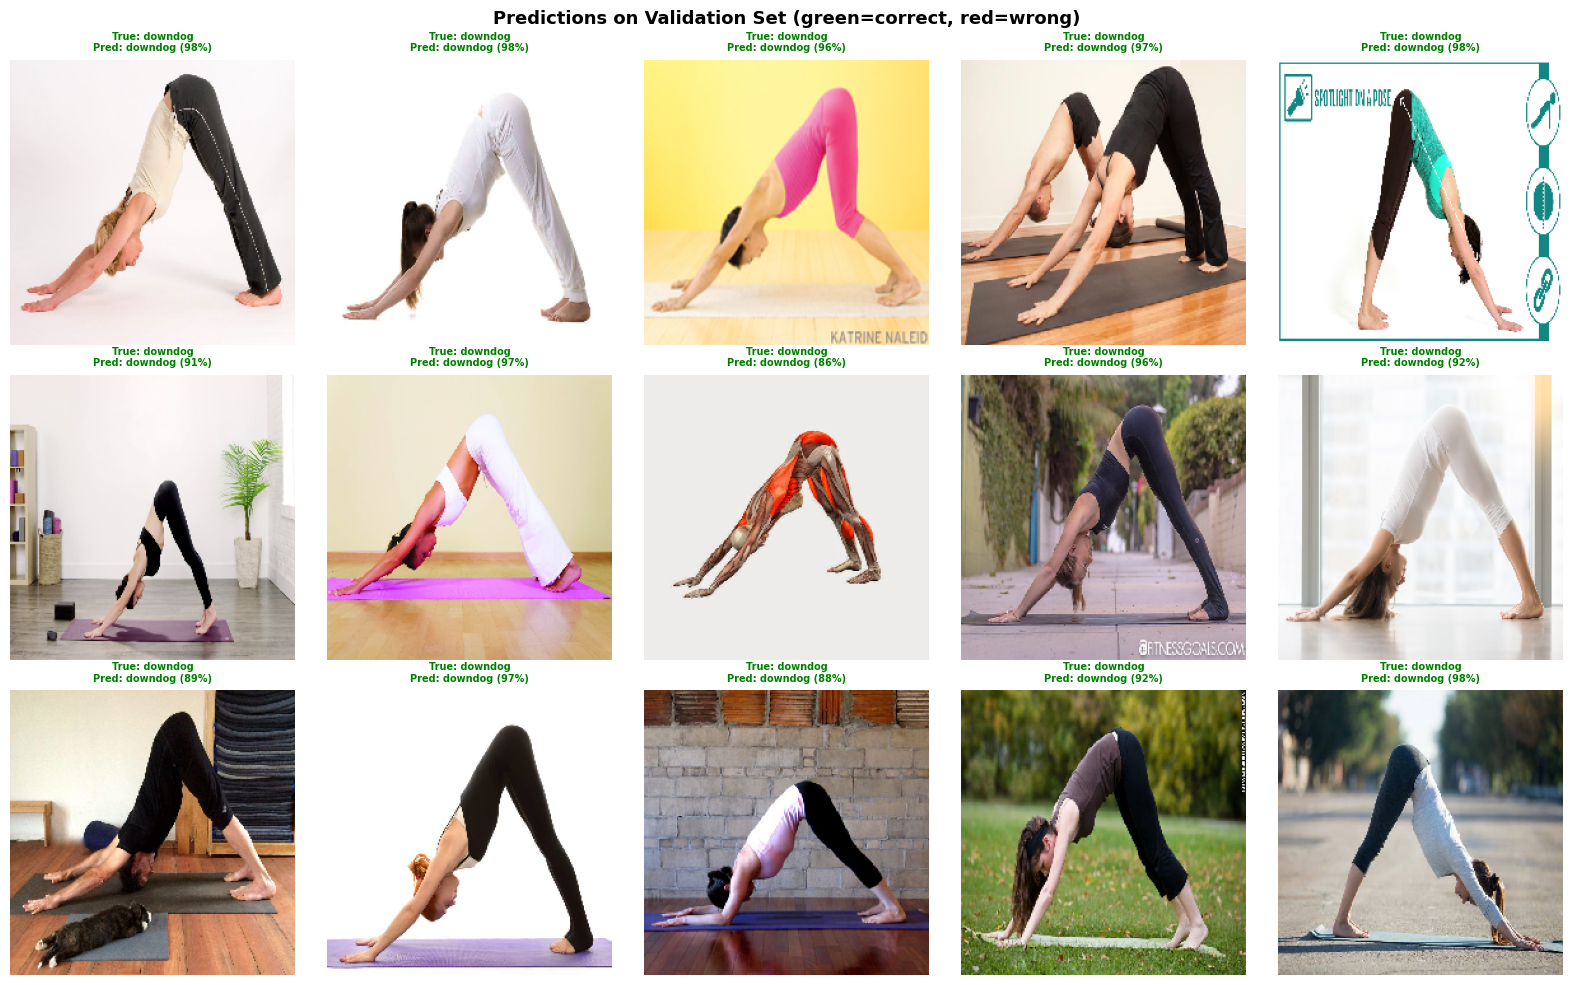

In [27]:
# Show predictions vs true labels on validation samples
best_model = model3  # Change to model1 or model2 if needed

val_gen.reset()
x_batch, y_batch = next(val_gen)
preds = best_model.predict(x_batch, verbose=0)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flatten()):
    if i >= len(x_batch):
        ax.axis('off'); continue
    ax.imshow(x_batch[i])
    true_label = CLASS_NAMES[np.argmax(y_batch[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf       = np.max(preds[i]) * 100
    color      = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.0f}%)',
                 fontsize=7, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predictions on Validation Set (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 📝 Conclusion
---

### Summary

In this project, we developed and compared **three deep learning models** for yoga pose image classification:

| Model | Approach | Key Characteristics |
|---|---|---|
| Model 1 — Basic CNN | From scratch | 3 conv blocks, lightweight, fast training |
| Model 2 — Deep CNN | From scratch | 5 conv blocks, L2 regularization, more capacity |
| Model 3 — MobileNetV2 | Transfer Learning | Pretrained on ImageNet, fine-tuned on yoga data |

### Key Findings

1. **Transfer learning significantly outperforms** training from scratch, confirming that pre-learned visual features are highly transferable to yoga pose recognition.
2. **Data augmentation** helped reduce overfitting across all models.
3. The **two-phase fine-tuning strategy** (freeze then unfreeze) proved effective for adapting the pretrained model.
4. **Visually similar poses** (e.g., warrior I vs warrior II) remain the main source of misclassification, as anticipated by the instructor.

### Limitations & Future Work

- A larger dataset would likely improve all models
- Trying **EfficientNet** or **Vision Transformers (ViT)** could yield further improvements
- Real-time video inference and pose estimation (e.g., MediaPipe) could complement the classifier
- Explainability tools like **Grad-CAM** could visualize which body regions each model focuses on